In [3]:
import torch                                 
import torchvision                           
import torchvision.transforms as transforms  
import torchvision.datasets as datasets     
import matplotlib.pyplot as plt              
import numpy as np                           
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim                   
import random
from torch.utils.data import TensorDataset, DataLoader
from dataloader import load_digit_data, load_face_data, get_subset
import time as t

device = ("cuda" if torch.cuda.is_available() else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")


The code below loads the respective training and testing data for both tasks using the load_digit_data function defined in ``dataloader.py``

In [4]:
X_train, y_train = load_digit_data("data/digitdata/trainingimages", "data/digitdata/traininglabels")

X_test, y_test = load_digit_data("data/digitdata/testimages", "data/digitdata/testlabels")

X_train_face, y_train_face = load_face_data("data/facedata/facedatatrain", "data/facedata/facedatatrainlabels")

X_test_face, y_test_face = load_face_data("data/facedata/facedatatest", "data/facedata/facedatatestlabels")


In [28]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)


print(X_train_face.shape)
print(y_train_face.shape)


def split_training_data(percent, x, y):

    train_size = int((percent) * y.shape[0])
    indices = torch.randperm(x.shape[0])


    x_train_cut = x[indices[:train_size]]
    y_train_cut = y[indices[:train_size]]

    return torch.from_numpy(x_train_cut), torch.from_numpy(y_train_cut)



(5000, 784)
(5000,)
(1000, 784)
(1000,)
(451, 4200)
(451,)


# Neural Network from Scratch:

The code below initializes weight matrices and bias vectors to create the manual neural network forward pass. The generator is set at the top of the cell for reproducibility. For now, we will implemement the forward and backward propagation from scratch.

There are some things that will be done differently for classification. In class, we were told to perform BCE loss with every single unnormalized logit value and sum the losses across each example. However, I am applying categorical crossentropy loss, with the softmax function:

$$
\text{softmax}(z_i)=\frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

This function will take in a logit vector and turn it into a probability distribution by normalizing the values by the expression above. The result is that the only logit that contributes to the loss of the training example is the ground true logit associated with the training example.

In [29]:
'''
Following structure of the neural network:
- Input layer will be the flattened training vectors
- First hidden layer will be of size 784 x 1000
- Second hidden layer will be of size 1000 x 100
- final layer will be of size 100 x 10

I am creating the weight matrices below:
'''


seed = 42
def generate_manual_model_digits():
    generator = torch.Generator().manual_seed(seed)

    hidden_layer_1 = ((torch.randn(784, 1000,    generator = generator)) * ((2/784)**0.5)).to(device)
    b_1 = (torch.randn(1,1000,                  generator = generator)).to(device)

    hidden_layer_2 = ((torch.randn(1000, 100,    generator = generator)) * ((2/1000)**0.5)).to(device)
    b_2  = (torch.randn(1,100,       generator = generator)).to(device)

    output_layer = ((torch.randn(100, 10,    generator = generator))* ((2/100)**0.5)).to(device)
    b_3 = (torch.randn(1,10,       generator = generator)).to(device)



    parameters = [hidden_layer_1, hidden_layer_2, output_layer, b_1, b_2, b_3]
    model = [(hidden_layer_1, b_1), (hidden_layer_2, b_2), (output_layer, b_3)]

    return parameters, model


def generate_manual_model_face():
    generator = torch.Generator().manual_seed(seed)

    hidden_layer_1 = ((torch.randn(4200, 1000,    generator = generator)) * ((2/4200)**0.5)).to(device)
    b_1 = (torch.randn(1,1000,                  generator = generator)).to(device)

    hidden_layer_2 = ((torch.randn(1000, 100,    generator = generator)) * ((2/1000)**0.5)).to(device)
    b_2  = (torch.randn(1, 100, generator=generator)).to(device)

    output_layer = ((torch.randn(100, 2,    generator = generator))* ((2/100)**0.5)).to(device)
    b_3 = (torch.randn(1,2,       generator = generator)).to(device)



    parameters = [hidden_layer_1, hidden_layer_2, output_layer, b_1, b_2, b_3]
    model = [(hidden_layer_1, b_1), (hidden_layer_2, b_2), (output_layer, b_3)]

    return parameters, model

In [30]:
params, p_list = generate_manual_model_digits()

hidden_layer_1 = params[0]

xc, yc = split_training_data(0.1, X_train, y_train)
xc = xc.to(device)
print(f"Size of input data before first linear transformation: {xc.shape}")

example_output = xc @ hidden_layer_1

print(f"Size of input data after first linear transformation: {example_output.shape}")

Size of input data before first linear transformation: torch.Size([500, 784])
Size of input data after first linear transformation: torch.Size([500, 1000])


In [31]:
'''
    Consider the forward pass function below. It traverses the tupled list of weight matrices and bias vectors per layer
    and performs the following operation: (f @ W) + b. This operation takes input batch of the previous layer and performs a
    linear transformation on the weight matrix, and then adds the bias vector (one bias value per neuron or row in the matrix).

    Note the activation function being ReLU, which is a squash at zero function. It is a piecewise function where y = 0 if x < 0
    and y = x otherwise. Because of this, the candidate derivative matrix for the ReLU function is just a matrix mask of 0's and 1's
    with a 1 in the derivative position of the value that was non-negative, and a 0 otherwise. Intuitively, ReLU fails to train neurons
    that have negative outputs, as the derivative in the computation graph is zero.

    The following function below also stores the post-activation derivatives of each hidden layer.
'''

from torch import Tensor


def forward_with_computation_graph(p_list, x_batch):
    relu_derivatives = []
    layer_outputs = []

    f = x_batch
    if type(x_batch) != Tensor: f = torch.from_numpy(f)
    f = f.to(device)
    for weights, bias in p_list[:-1]:
        pre_activation = (f @ weights) + bias
        f = F.relu(pre_activation)
        layer_outputs.append(f)

        relu_derivative = (f > 0)
        relu_derivatives.append(relu_derivative)
    output_weight, output_bias = p_list[-1]

    logits = (f @ output_weight) + output_bias
    return logits, relu_derivatives, layer_outputs


In [32]:
params, param_list = generate_manual_model_digits()


out, layer_derivs, layer_outputs = forward_with_computation_graph(param_list, xc)

print(out.shape)
print(len(layer_derivs))
print(len(layer_outputs))

torch.Size([500, 10])
2
2


In [33]:


def train_model(model_list, alpha, epochs, x_train, y_train, model_losses, train_percentage, bs):
    loss = nn.CrossEntropyLoss(reduction='mean')
    x, y = split_training_data(train_percentage, x_train, y_train)
    dataset = TensorDataset(x, y)
    train_loader = DataLoader(dataset, bs, shuffle=True)

    start_time = t.perf_counter()
    for epoch in range(epochs):
        epoch_losses, num_batches = 0.0, 0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits, layer_derivatives, layer_outputs = forward_with_computation_graph(model_list, x_batch)

            layer_1_post_activation_derivative, layer_2_post_activation_derivative = layer_derivatives

            layer_1_output, layer_2_output = layer_outputs

            (W1, b1), (W2, b2), (W_out, b_out) = model_list

            batch_loss = loss(logits, y_batch)

            epoch_losses += batch_loss
            num_batches += 1


            probs = F.softmax(logits, dim=1)

            one_hot = torch.zeros_like(logits)
            one_hot[torch.arange(y_batch.shape[0], device=logits.device), y_batch] = 1

            dL_dlogits = (probs - one_hot) / y_batch.shape[0]

            W_out_derivative = layer_2_output.T @ dL_dlogits
            b_out_derivative = torch.sum(dL_dlogits, dim=0)
            global_out_derivative = dL_dlogits @ W_out.T

            global_layer_2_derivative = layer_2_post_activation_derivative * global_out_derivative

            W2_derivative = layer_1_output.T @ global_layer_2_derivative
            b2_derivative = torch.sum(global_layer_2_derivative, dim=0)
            layer_1_post_activation = global_layer_2_derivative @ W2.T

            global_layer_1_derivative = layer_1_post_activation * layer_1_post_activation_derivative

            W1_derivative = x_batch.T @ global_layer_1_derivative
            b1_derivative = torch.sum(global_layer_1_derivative, dim=0)

            b_out -= (alpha * b_out_derivative)
            W_out -= alpha * W_out_derivative

            b2 -= (alpha *b2_derivative)
            W2 -= (alpha *W2_derivative)

            b1 -= (alpha *b1_derivative)
            W1 -=(alpha * W1_derivative)

        model_losses[epoch] = (epoch_losses / num_batches)
    end_time = t.perf_counter()
    return model_losses, (end_time - start_time)


def eval_model(model_list, xtest, ytest):
    xtest = torch.from_numpy(xtest).to(device)
    ytest = torch.from_numpy(ytest).to(device)


    loss = nn.CrossEntropyLoss(reduction='mean')
    with torch.no_grad():
        logits, _, _ = forward_with_computation_graph(model_list, xtest)

        total_loss = loss(logits, ytest)
    
        probs = F.softmax(logits, dim=1)

        preds = probs.argmax(dim=1)

        correct = (preds == ytest).sum()

        

    return total_loss, correct / ytest.shape[0]






In [34]:
losses = {}
eps = 100
percent = 0.5
batch = 64
learning_rate = 0.001

loss_graph, time_taken = train_model(param_list, learning_rate, eps, X_train, y_train, losses, percent, batch)

print(f"Final Batch Loss: {loss_graph[eps-1]}")

Final Batch Loss: 0.36764734983444214


In [35]:
from statistics import mean, stdev

percents = [round(i * 0.1, ndigits=2) for i in range(1, 11)]

def train_all_models(percents, num_runs, xdatatrain, ydatatrain, xdatatest, ydatatest, task_type):
    model_time_averages = []
    model_accuracy_averages = []

    model_accuracy_stds = []
    for percent in percents:
        running_time = []
        running_acc = []
        _, model = generate_manual_model_digits()


        for _ in range(num_runs):
            percent_model_losses = {}
            model = None
            if task_type == 'digits':
                _, model = generate_manual_model_digits()
            else: 
                _, model = generate_manual_model_face()
            _, time = train_model(model, learning_rate, eps, xdatatrain, ydatatrain, percent_model_losses, percent, batch)
            running_time.append(time)
            
            _, final_acc = eval_model(model, xdatatest, ydatatest)
            running_acc.append(final_acc.item())
        

        model_time_averages.append(mean(running_time))
        model_accuracy_averages.append(mean(running_acc))
        model_accuracy_stds.append(stdev(running_acc))
    
    return model_time_averages, model_accuracy_averages, model_accuracy_stds
        



In [36]:
model_times_face, model_accuracies_face, model_accuracy_stdev_face = train_all_models(percents, 5, X_train_face,
                                                                                       y_train_face, X_test_face, y_test_face,
                                                                                       task_type='faces')


model_times_digit, model_accuracies_digit, model_accuracy_stdev_digit = train_all_models(percents, 5, X_train,
                                                                                          y_train, X_test, y_test, task_type='digits')

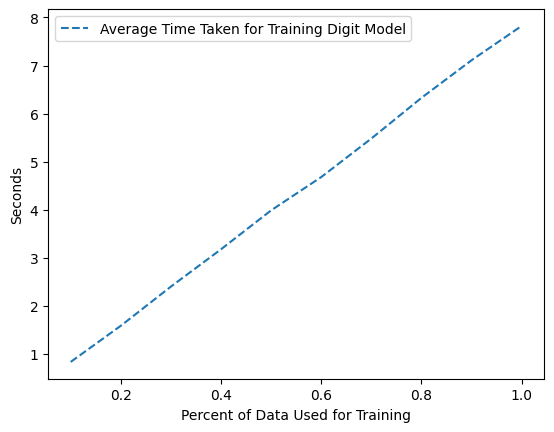

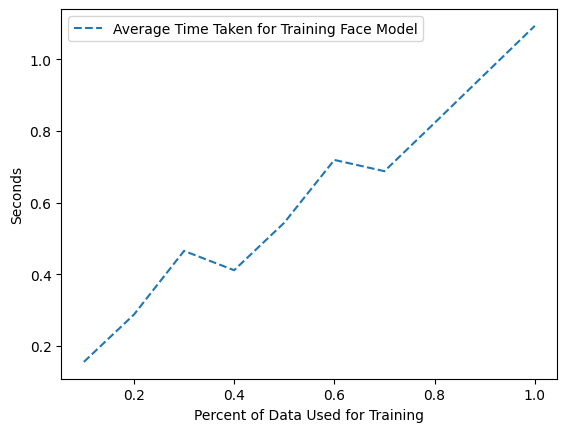

In [51]:
plt.plot(percents, model_times_digit, '--', label="Average Time Taken for Training Digit Model")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Seconds")
plt.legend()
plt.show()

plt.plot(percents, model_times_face, '--', label="Average Time Taken for Training Face Model")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Seconds")
plt.legend()
plt.show()

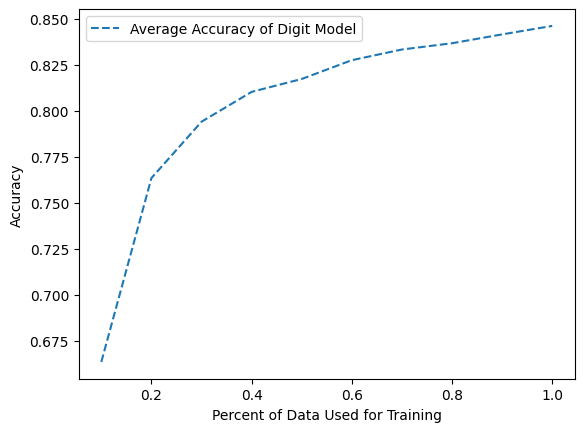

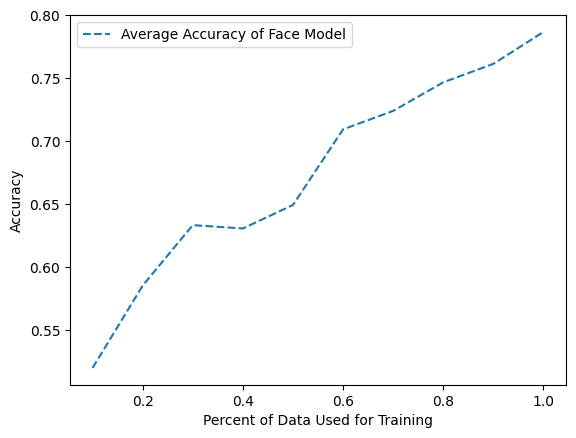

In [52]:
plt.plot(percents, model_accuracies_digit, '--', label="Average Accuracy of Digit Model")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(percents, model_accuracies_face, '--', label="Average Accuracy of Face Model")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

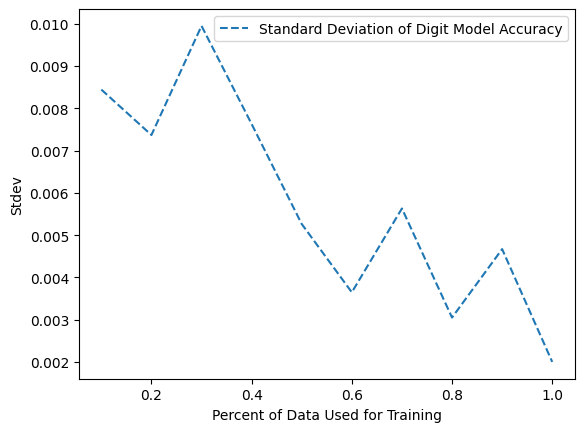

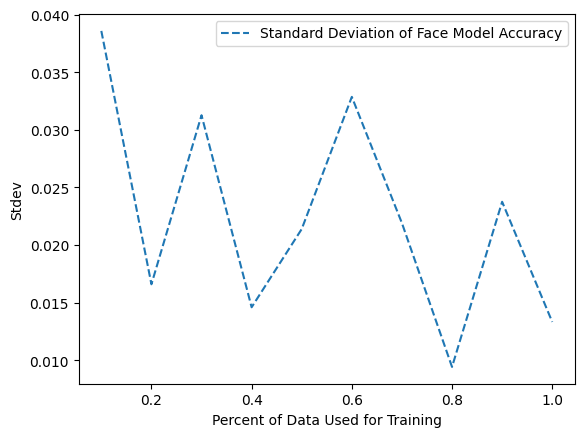

In [53]:
plt.plot(percents, model_accuracy_stdev_digit, '--', label="Standard Deviation of Digit Model Accuracy")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Stdev")
plt.legend()
plt.show()


plt.plot(percents, model_accuracy_stdev_face, '--', label="Standard Deviation of Face Model Accuracy")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Stdev")
plt.legend()
plt.show()

In [40]:
class Digit_NN(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.ModuleList()

        self.layers.append(torch.nn.Linear(784, 1000))
        self.layers.append(torch.nn.Linear(1000, 100))
        self.layers.append(torch.nn.Linear(100, 10))

    def forward(self, x):
        output = x

        for layer in self.layers[:-1]:
            output = layer( output )

            output = F.relu(output)

        logits = self.layers[-1]( output )
        return logits
    

class Face_NN(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.ModuleList()

        self.layers.append(torch.nn.Linear(4200, 1000))
        self.layers.append(torch.nn.Linear(1000, 100))
        self.layers.append(torch.nn.Linear(100, 2))

    def forward(self, x):
        output = x

        for layer in self.layers[:-1]:
            output = layer( output )

            output = F.relu(output)

        logits = self.layers[-1]( output )
        return logits

In [41]:
def train_nn(model, alpha, epochs, x_train, y_train, model_losses, train_percentage, bs):
    optimizer = optim.Adam(model.parameters(), lr=alpha)
    loss_fn = nn.CrossEntropyLoss(reduction='mean')
    x, y = split_training_data(train_percentage, x_train, y_train)
    dataset = TensorDataset(x, y)
    train_loader = DataLoader(dataset, bs, shuffle=True)

    start_time = t.perf_counter()
    for epoch in range(epochs):
        batches = 0
        epoch_losses, num_batches = 0.0, 0
        for x_batch, y_batch in train_loader:
            batches +=1
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model( x_batch )

            loss = loss_fn(logits, y_batch)

            epoch_losses += loss.item()
            

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            num_batches +=1

        model_losses[epoch] = (epoch_losses / num_batches)
    end_time = t.perf_counter()
    return model_losses, (end_time - start_time)


def eval_nn(model, xtest, ytest):
    xtest = torch.from_numpy(xtest).to(device)
    ytest = torch.from_numpy(ytest).to(device)

    loss_fn = nn.CrossEntropyLoss(reduction='mean')

    with torch.no_grad():
        logits = model(xtest)

        total_loss = loss_fn(logits, ytest)
    
        probs = F.softmax(logits, dim=1)

        preds = probs.argmax(dim=1)

        correct = (preds == ytest).sum()

        

    return total_loss, correct / ytest.shape[0]






In [42]:
test_NN = Digit_NN()
test_NN.to(device)

losses, time = train_nn(test_NN, 0.001, 20, X_train, y_train, {}, 0.5, 64)

In [43]:
l, a = eval_nn(test_NN, X_test, y_test)


print(f"Test NN Accuracy on Digit Data: {a.item()}")

Test NN Accuracy on Digit Data: 0.8899999856948853


In [44]:
test_NN_Face = Face_NN()
test_NN_Face.to(device)

losses, time = train_nn(test_NN_Face, 0.001, 20, X_train_face, y_train_face, {}, 0.5, 64)

In [45]:
l, a = eval_nn(test_NN_Face, X_test_face, y_test_face)


print(f"Test NN Accuracy on Face Data: {a.item()}")

Test NN Accuracy on Face Data: 0.8666666746139526


In [46]:
def train_all_nns(percents, num_runs, xdatatrain, ydatatrain, xdatatest, ydatatest, task_type):
    model_time_averages = []
    model_accuracy_averages = []

    model_accuracy_stds = []
    for percent in percents:
        running_time = []
        running_acc = []


        for _ in range(num_runs):
            percent_model_losses = {}
            model = None
            if task_type == 'digits':
                model = Digit_NN()
                
            else: 
                model = Face_NN()
            model.to(device)
            losses, time = train_nn(model, learning_rate, eps, xdatatrain, ydatatrain, {}, percent, 64)
            running_time.append(time)
            
            _, final_acc = eval_nn(model, xdatatest, ydatatest)
            running_acc.append(final_acc.item())
        

        model_time_averages.append(mean(running_time))
        model_accuracy_averages.append(mean(running_acc))
        model_accuracy_stds.append(stdev(running_acc))
    
    return model_time_averages, model_accuracy_averages, model_accuracy_stds
        



In [47]:
nn_times_face, nn_accuracies_face, nn_accuracy_stdev_face = train_all_nns(percents, 5, X_train_face,
                                                                                       y_train_face, X_test_face, y_test_face,
                                                                                       task_type='faces')


nn_times_digit, nn_accuracies_digit, nn_accuracy_stdev_digit = train_all_nns(percents, 5, X_train,
                                                                                          y_train, X_test, y_test, task_type='digits')

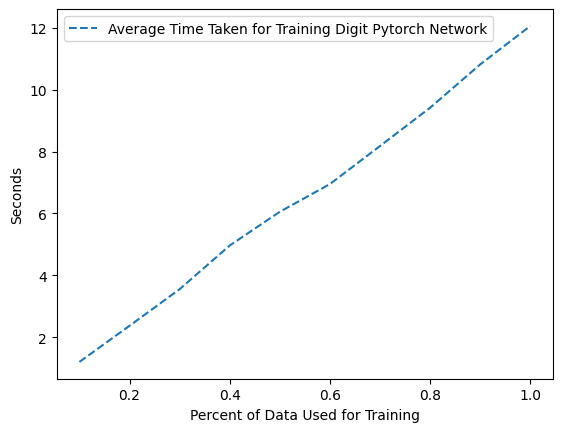

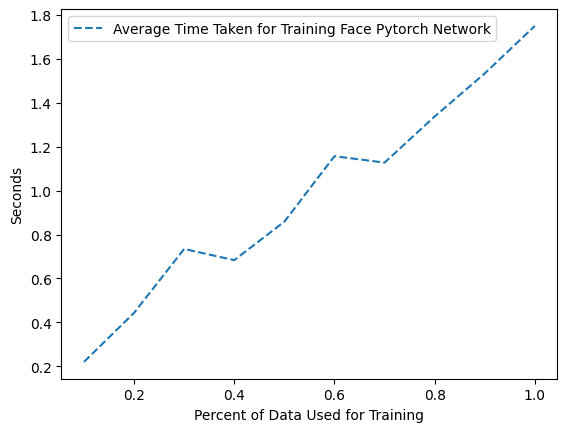

In [54]:
plt.plot(percents, nn_times_digit, '--', label="Average Time Taken for Training Digit Pytorch Network")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Seconds")
plt.legend()
plt.show()

plt.plot(percents, nn_times_face, '--', label="Average Time Taken for Training Face Pytorch Network")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Seconds")
plt.legend()
plt.show()

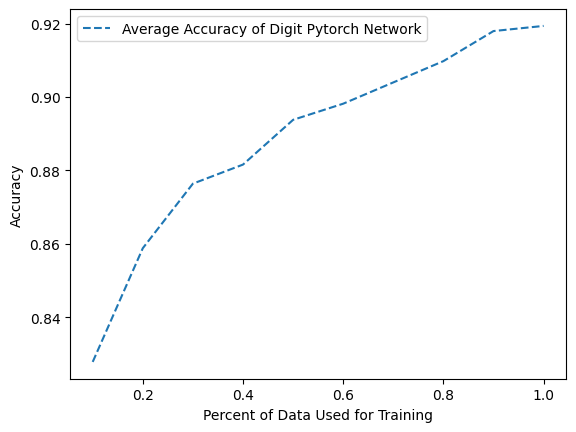

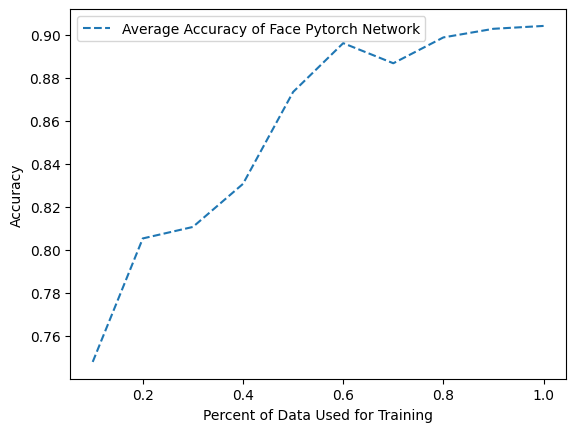

In [55]:
plt.plot(percents, nn_accuracies_digit, '--', label="Average Accuracy of Digit Pytorch Network")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(percents, nn_accuracies_face, '--', label="Average Accuracy of Face Pytorch Network")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

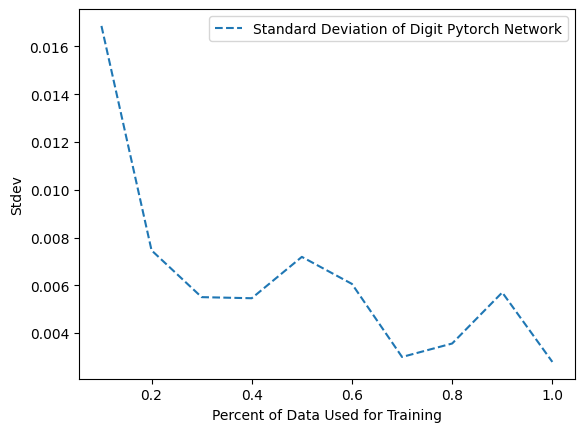

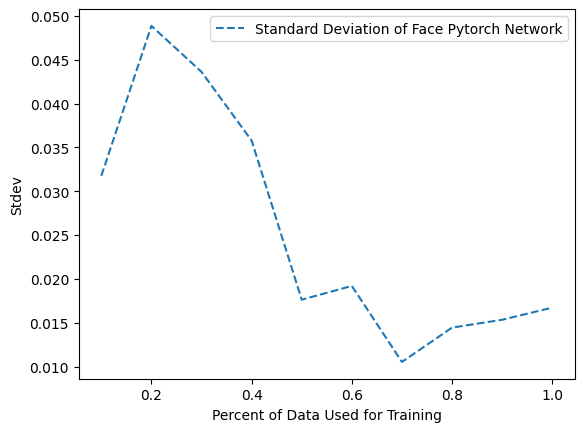

In [56]:
plt.plot(percents, nn_accuracy_stdev_digit, '--', label="Standard Deviation of Digit Pytorch Network")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Stdev")
plt.legend()
plt.show()

plt.plot(percents, nn_accuracy_stdev_face, '--', label="Standard Deviation of Face Pytorch Network")
plt.xlabel("Percent of Data Used for Training")
plt.ylabel("Stdev")
plt.legend()
plt.show()